# Step 3: Feature Engineering (Coarse-Classing)

Coarse-classing for PD model variables using helper functions in `src/pd_feature_engineering.py`.


## Variables Covered

1. Discrete (`feature_type="unordered_discrete"`): `grade`, `home_ownership`, `addr_state`, `verification_status`, `purpose`, `initial_list_status`  
2. Standard continuous (`feature_type="continuous"`): `term_int`, `emp_length_int`, `delinq_2yrs`, `inq_last_6mths`, `open_acc`, `pub_rec`, `acc_now_delinq`, `mths_since_issue_d`, `int_rate`, `funded_amnt`, `mths_since_earliest_cr_line`, `total_acc`, `total_rev_hi_lim`, `installment`  
3. Tuned continuous (still `feature_type="continuous"`, but highlighted separately because of parameter emphasis rather than a different processing branch): `annual_inc`, `dti` / `dti_factor`, `mths_since_last_delinq`, `mths_since_last_record`

So, in implementation terms, groups (2) and (3) go through the same continuous coarse-classing pipeline; the difference is in configuration choices and interpretation, such as higher initial bin counts, monotonic WoE checks, or keeping missing values as an explicit `MISSING` bin.


## Notebook Overview

This notebook fits WoE-based coarse-classing rules on the general-preparation output and converts those rules into model-ready indicator features.

The main workflow is:
- load the prepared train/test datasets from Step 2
- verify that the binary target is available
- fit feature-level coarse-classing pipelines on `train_df` and apply them to `test_df`
- inspect selected WoE/IV reports for interpretability
- save engineered parquet outputs together with per-feature audit tables

### Modeling Notes
- Binning and grouping decisions should be learned from the training split only.
- The saved WoE report CSV files provide an audit trail for cut points, merged categories, and final bin definitions.

In [16]:
import sys
sys.path.insert(0, '/home/jovyan/work/src')

import pandas as pd
from pyspark.sql import functions as F
from spark_utils import get_spark_session, save_parquet
from pd_feature_engineering import fit_pd_coarse_classing, plot_by_woe, add_all_bin_indicator_columns, DF_FEATURES, plot_woe_history_compare


## 3.1 Load Train/Test Data


Only the identifier, target, and the feature set declared in `DF_FEATURES` are loaded here.

Keeping the notebook scoped to the curated feature list helps maintain a stable schema and makes the downstream binning output easier to audit.

In [17]:
spark = get_spark_session()

train_path = '/home/jovyan/work/data/parquet/accepted_general_prep_train.parquet'
test_path = '/home/jovyan/work/data/parquet/accepted_general_prep_test.parquet'

train_df = spark.read.parquet(train_path).select("id","good_bad", *DF_FEATURES)
test_df = spark.read.parquet(test_path).select("id","good_bad", *DF_FEATURES)

print(f'Train rows: {train_df.count()}, columns: {len(train_df.columns)}')
print(f'Test rows: {test_df.count()}, columns: {len(test_df.columns)}')


Spark driver memory: 7g
Train rows: 1807770, columns: 26
Test rows: 452931, columns: 26


## 3.2 Ensure Target Column (`good_bad`)


In [18]:
TARGET_COL = 'good_bad'

if TARGET_COL not in train_df.columns:
    train_df = train_df.withColumn(
        TARGET_COL,
        F.when(F.col('loan_status').isin(
            'Charged Off',
            'Default',
            'Does not meet the credit policy. Status:Charged Off',
            'Late (31-120 days)',
        ), F.lit(0)).otherwise(F.lit(1))
    )

if TARGET_COL not in test_df.columns:
    test_df = test_df.withColumn(
        TARGET_COL,
        F.when(F.col('loan_status').isin(
            'Charged Off',
            'Default',
            'Does not meet the credit policy. Status:Charged Off',
            'Late (31-120 days)',
        ), F.lit(0)).otherwise(F.lit(1))
    )

train_df.groupBy(TARGET_COL).count().show()


+--------+-------+
|good_bad|  count|
+--------+-------+
|       1|1575678|
|       0| 232092|
+--------+-------+



## 3.3 Run Coarse-Classing Pipelines


This is the core modeling-prep step.

`fit_pd_coarse_classing(...)` fits per-feature binning/grouping rules on the training data, applies the resolved rules to both splits, and returns both the transformed datasets and supporting artifacts such as fitted pipelines, report tables, and feature-name mappings.

In [19]:
train_fe, test_fe, pipelines, reports, name_mapping, missing_vars = fit_pd_coarse_classing(
    train_df,
    test_df,
    target_col=TARGET_COL,
)

print(f'Pipelines fitted: {len(pipelines)}')
print('Mapped business variable -> resolved column:')
for k, v in name_mapping.items():
    print(f'  {k} -> {v}')

if missing_vars:
    print('Missing variables (not found in dataframe):', missing_vars)

print(f'Train engineered columns: {len(train_fe.columns)}')
print(f'Test engineered columns: {len(test_fe.columns)}')


Pipelines fitted: 24
Mapped business variable -> resolved column:
  grade -> grade
  home_ownership -> home_ownership
  addr_state -> addr_state
  verification_status -> verification_status
  purpose -> purpose
  initial_list_status -> initial_list_status
  term_int -> term_int
  emp_length_int -> emp_length_int
  delinq_2yrs -> delinq_2yrs
  inq_last_6mths -> inq_last_6mths
  open_acc -> open_acc
  pub_rec -> pub_rec
  acc_now_delinq -> acc_now_delinq
  mths_since_issue_d -> mths_since_issue_d
  int_rate -> int_rate
  funded_amnt -> funded_amnt
  mths_since_earliest_cr_line -> mths_since_earliest_cr_line
  total_acc -> total_acc
  total_rev_hi_lim -> total_rev_hi_lim
  installment -> installment
  annual_inc -> annual_inc
  dti -> dti
  mths_since_last_delinq -> mths_since_last_delinq
  mths_since_last_record -> mths_since_last_record
Train engineered columns: 98
Test engineered columns: 98


## 3.4 Example Reports


The report cells below are spot checks rather than a full validation pass.

They are useful for confirming that the final grouping is directionally sensible, that WoE patterns are not erratic after merging, and that null-heavy variables are handled explicitly when needed.

In [20]:
pipelines["annual_inc"].history_

[{'iter': 0,
  'table':     __order__               bin  n_obs  prop_good  prop_n_obs   n_good  \
  0           0     (-inf, 22200]  44558   0.853068    0.024648  38011.0   
  1           1    (22200, 27800]  46315   0.845536    0.025620  39161.0   
  2           2    (27800, 30000]  17859   0.840641    0.009879  15013.0   
  3           3    (30000, 34000]  68070   0.846335    0.037654  57610.0   
  4           4    (34000, 36000]  43896   0.847799    0.024282  37215.0   
  5           5    (36000, 38688]  49172   0.848105    0.027200  41703.0   
  6           6    (38688, 40000]  11877   0.849204    0.006570  10086.0   
  7           7    (40000, 42000]  63341   0.854833    0.035038  54146.0   
  8           8    (42000, 45000]  52925   0.849183    0.029276  44943.0   
  9           9    (45000, 46000]  48033   0.853059    0.026570  40975.0   
  10         10    (46000, 48600]  51434   0.856690    0.028452  44063.0   
  11         11    (48600, 50000]  13296   0.856273    0.007355  1

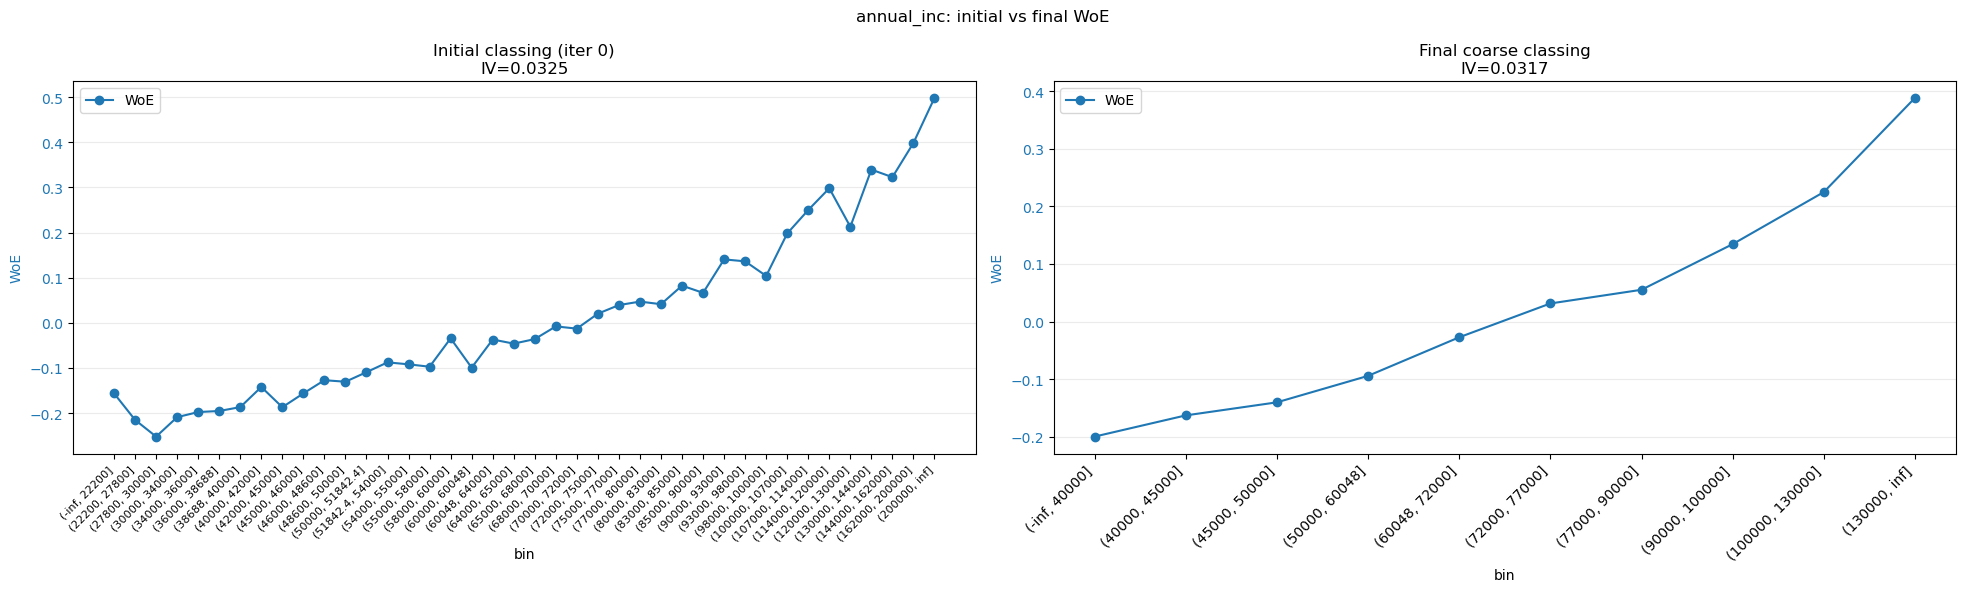

In [21]:
before_tbl, after_tbl = plot_woe_history_compare(
    pipelines["annual_inc"],
    title="annual_inc: initial vs final WoE"
)

In [22]:
pipelines["addr_state"].history_

[{'iter': 0,
  'table':         bin   n_obs  prop_good  prop_n_obs    n_good    n_bad  prop_n_good  \
  0        IA       9   0.777778    0.000005       7.0      2.0     0.000004   
  1        AL   21860   0.844282    0.012092   18456.0   3404.0     0.011713   
  2        MS   10145   0.848398    0.005612    8607.0   1538.0     0.005462   
  3        AR   13702   0.849438    0.007580   11639.0   2063.0     0.007387   
  4        OK   16643   0.850388    0.009206   14153.0   2490.0     0.008982   
  5        LA   20586   0.850967    0.011388   17518.0   3068.0     0.011118   
  6        NV   26034   0.855036    0.014401   22260.0   3774.0     0.014127   
  7        NM    9523   0.858343    0.005268    8174.0   1349.0     0.005188   
  8        NY  148860   0.858753    0.082345  127834.0  21026.0     0.081130   
  9        SD    3622   0.861403    0.002004    3120.0    502.0     0.001980   
  10       FL  129363   0.861614    0.071559  111461.0  17902.0     0.070738   
  11       HI    8

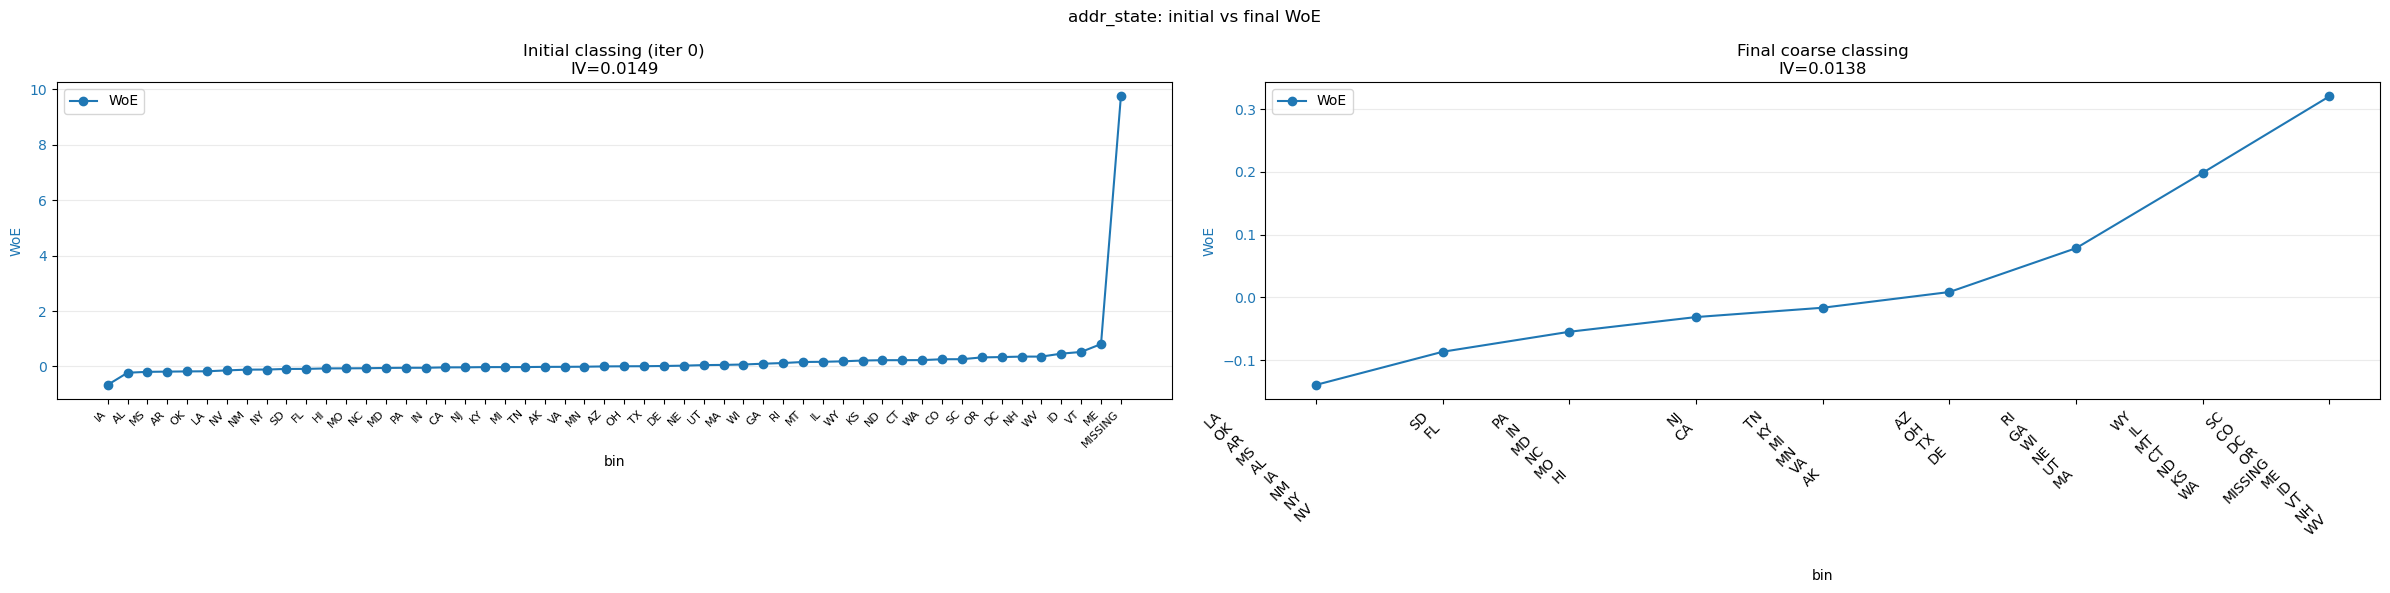

In [23]:
before_tbl, after_tbl = plot_woe_history_compare(
    pipelines["addr_state"],
    title="addr_state: initial vs final WoE"
)

In [24]:
# WoE/IV table examples
example_feats = [ "annual_inc", "dti_factor", "mths_since_last_delinq", "mths_since_last_record" ]
for feat in example_feats:
    resolved = name_mapping.get(feat)
    if resolved in reports:
        print(f'=== {feat} (resolved: {resolved}) ===')
        display(reports[resolved].head(15))


=== annual_inc (resolved: annual_inc) ===


,__order__,bin,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV_component,IV
0,0,"(-inf, 40000]",281747,0.847565,0.155853,238799.0,42948.0,0.151553,0.185047,-0.199675,NaN,NaN,0.006688,0.03169
1,1,"(40000, 45000]",116266,0.852261,0.064315,99089.0,17177.0,0.062887,0.074009,-0.162860,0.004696,0.036815,0.001811,0.03169
2,2,"(45000, 50000]",112763,0.855094,0.062377,96423.0,16340.0,0.061195,0.070403,-0.140178,0.002833,0.022682,0.001291,0.03169
3,3,"(50000, 60048]",303184,0.860695,0.167712,260949.0,42235.0,0.165611,0.181975,-0.094231,0.005601,0.045947,0.001542,0.03169
4,4,"(60048, 72000]",213027,0.868533,0.117840,185021.0,28006.0,0.117423,0.120668,-0.027257,0.007838,0.066975,0.000088,0.03169
5,5,"(72000, 77000]",98209,0.875093,0.054326,85942.0,12267.0,0.054543,0.052854,0.031453,0.006560,0.058709,0.000053,0.03169
6,6,"(77000, 90000]",174976,0.877669,0.096791,153571.0,21405.0,0.097463,0.092226,0.055231,0.002576,0.023779,0.000289,0.03169
7,7,"(90000, 100000]",112528,0.885922,0.062247,99691.0,12837.0,0.063269,0.055310,0.134437,0.008253,0.079205,0.001070,0.03169
8,8,"(100000, 130000]",207642,0.894747,0.114861,185787.0,21855.0,0.117909,0.094165,0.224864,0.008825,0.090427,0.005339,0.03169
9,9,"(130000, inf]",187428,0.909181,0.103679,170406.0,17022.0,0.108148,0.073342,0.388370,0.014434,0.163506,0.013518,0.03169


=== mths_since_last_delinq (resolved: mths_since_last_delinq) ===


,__order__,bin,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV_component,IV
0,0,"(-inf, 19]",257281,0.855730,0.142320,220163.0,37118.0,0.139726,0.159928,-0.135041,NaN,NaN,0.002728,0.005024
1,1,"(19, 34]",211332,0.865856,0.116902,182983.0,28349.0,0.116130,0.122146,-0.050506,0.010126,0.084535,0.000304,0.005024
2,2,"(34, 49]",177556,0.870435,0.098218,154551.0,23005.0,0.098085,0.099120,-0.010495,0.004580,0.040011,0.000011,0.005024
3,3,"(49, inf]",235108,0.868605,0.130054,204216.0,30892.0,0.129605,0.133102,-0.026626,0.001830,0.016132,0.000093,0.005024
4,4,MISSING,926493,0.878328,0.512506,813765.0,112728.0,0.516454,0.485704,0.061387,0.009723,0.088013,0.001888,0.005024


=== mths_since_last_record (resolved: mths_since_last_record) ===


,__order__,bin,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV_component,IV
0,0,"(-inf, 69]",120732,0.836473,0.066785,100989.0,19743.0,0.064092,0.085065,-0.283094,NaN,NaN,0.005937,0.011675
1,1,"(69, inf]",166714,0.848159,0.092221,141400.0,25314.0,0.089739,0.109069,-0.195072,0.011687,0.088023,0.003771,0.011675
2,2,MISSING,1520324,0.876977,0.840994,1333289.0,187035.0,0.846168,0.805866,0.048801,0.028818,0.243873,0.001967,0.011675


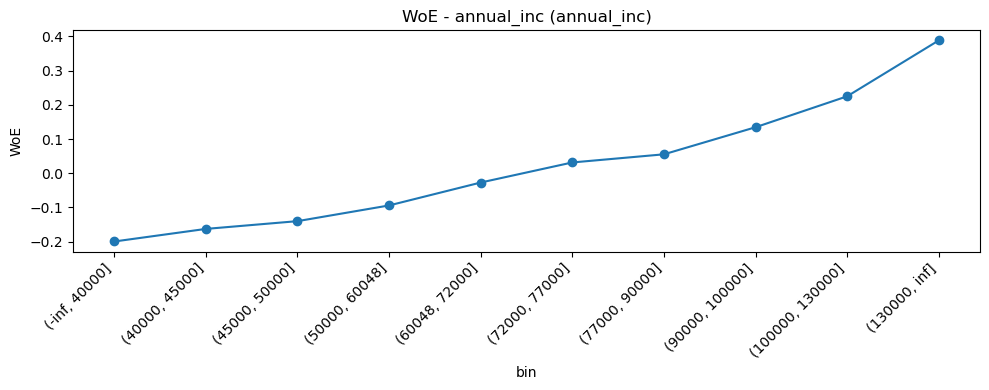

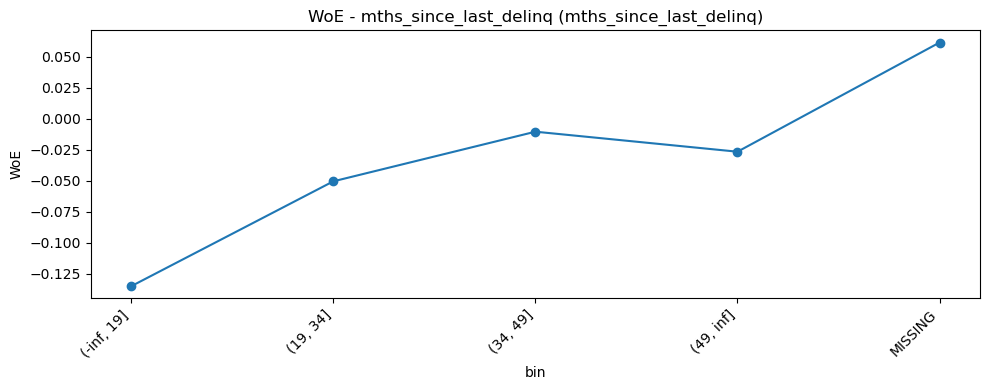

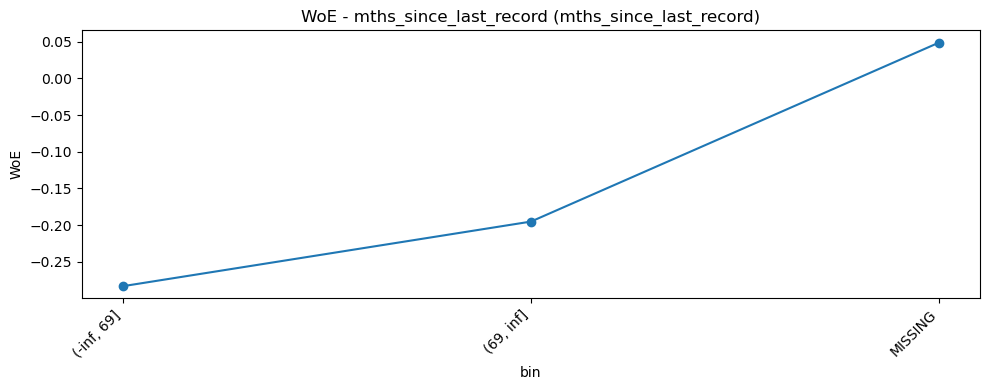

In [25]:
# Optional visual checks
for feat in ["annual_inc", "dti_factor", "mths_since_last_delinq", "mths_since_last_record"]:
    resolved = name_mapping.get(feat)
    if resolved in reports:
        plot_by_woe(reports[resolved], title=f'WoE - {feat} ({resolved})')


In [26]:
# Expand the final coarse classes into indicator columns used by the baseline model.
train_fe_bins = add_all_bin_indicator_columns(train_fe, pipelines, drop_grp_cols=False)
test_fe_bins = add_all_bin_indicator_columns(test_fe, pipelines, drop_grp_cols=False)

In [27]:
train_fe.select("addr_state", *[c for c in train_fe.columns if c.startswith("addr_state")]).show(20, truncate=False)

+----------+----------+--------------------+----------------------------------------------------+---------------------+
|addr_state|addr_state|addr_state__base_grp|addr_state_grp                                      |addr_state_woe       |
+----------+----------+--------------------+----------------------------------------------------+---------------------+
|AR        |AR        |AR                  |LA | OK | AR | MS | AL | IA | NM | NY | NV          |-0.13932467779184698 |
|TN        |TN        |TN                  |TN | KY | MI | MN | VA | AK                         |-0.016477076476022184|
|VA        |VA        |VA                  |TN | KY | MI | MN | VA | AK                         |-0.016477076476022184|
|CA        |CA        |CA                  |NJ | CA                                             |-0.03133883133779203 |
|TX        |TX        |TX                  |AZ | OH | TX | DE                                   |0.008553826584255114 |
|KS        |KS        |KS               

## 3.5 Save Outputs


Before saving, the notebook removes intermediate grouping and WoE columns so the final parquet files stay focused on the binary indicator representation.

This makes the saved datasets easier to plug into downstream modeling notebooks while keeping the detailed WoE logic available separately in the exported report tables.

In [28]:
# Drop intermediate group/WoE helper columns and the original raw feature columns.
# The saved feature set should contain the final model-ready indicators plus keys/target.
drop_cols_train = [
    c for c in train_fe_bins.columns
    if c.endswith("_grp") or c.endswith("_woe") or c.endswith("__base_grp")
]
drop_cols_test = [
    c for c in test_fe_bins.columns
    if c.endswith("_grp") or c.endswith("_woe") or c.endswith("__base_grp")
]

train_fe_bins = train_fe_bins.drop(*drop_cols_train)
train_fe_bins = train_fe_bins.drop(*DF_FEATURES)
train_fe_bins.show(20)
test_fe_bins = test_fe_bins.drop(*drop_cols_test)
test_fe_bins = test_fe_bins.drop(*DF_FEATURES)
test_fe_bins.show(20)

+---------+--------+-------+---------------+-------+-----------+-------+------------------------------+-----------------------------------+------------------+----------------------+----------------------------+-------------------------------------+----------------+----------------+----------------------------+-------------------------------+----------------------------+---------------------------------------------+----------------------------------+---------------------------------------+----------------------------+-----------------------------------------------------------+-------------------------------+------------------------+-----------------------------------------------------------------------------+-----------------------------+---------------------+----------------+---------------------+-----------------------+--------------------+--------------------+--------------------+---------------------+-----------------+-------------------+--------------------+----------------------+-

In [29]:
new_cols_train = [c for c in train_fe_bins.columns]
new_cols_test = [c for c in test_fe_bins.columns]

print("New columns in train_fe:")
for c in new_cols_train:
    print(c)

print("\nNew columns in test_fe:")
for c in new_cols_test:
    print(c)



New columns in train_fe:
id
good_bad
grade_B
grade_A|MISSING
grade_D
grade_F|G|E
grade_C
home_ownership_NONE|OTHER|RENT
home_ownership_MORTGAGE|MISSING|ANY
home_ownership_OWN
addr_state_AZ|OH|TX|DE
addr_state_PA|IN|MD|NC|MO|HI
addr_state_LA|OK|AR|MS|AL|IA|NM|NY|NV
addr_state_SD|FL
addr_state_NJ|CA
addr_state_RI|GA|WI|NE|UT|MA
addr_state_WY|IL|MT|CT|ND|KS|WA
addr_state_TN|KY|MI|MN|VA|AK
addr_state_SC|CO|DC|OR|MISSING|ME|ID|VT|NH|WV
verification_status_SourceVerified
verification_status_NotVerified|MISSING
verification_status_Verified
purpose_wedding|other|medical|vacation|house|major_purchase
purpose_credit_card|MISSING|car
purpose_home_improvement
purpose_debt_consolidation|moving|renewable_energy|educational|small_business
initial_list_status_w|MISSING
initial_list_status_f
term_int_(36,60]
term_int_(60,MISSING]
emp_length_int_(10,inf]
emp_length_int_(1,2]
emp_length_int_(0,1]
emp_length_int_(2,6]
emp_length_int_(6,10]
delinq_2yrs_(0,1]
delinq_2yrs_(1,inf]
inq_last_6mths_(1,2]
inq_las

In [30]:
# Build a combined baseline table in addition to the train/test feature files.
full_baseline = train_fe_bins.unionByName(test_fe_bins, allowMissingColumns=True)

save_parquet(train_fe_bins, '/home/jovyan/work/data/parquet/features_pd_train.parquet')
save_parquet(test_fe_bins, '/home/jovyan/work/data/parquet/features_pd_test.parquet')
save_parquet(full_baseline, '/home/jovyan/work/data/parquet/features_baseline.parquet')

# Save WoE reports for auditability
for resolved_col, rep in reports.items():
    rep.to_csv(f'/home/jovyan/work/outputs/tables/woe_report_{resolved_col}.csv', index=False)

print('Saved parquet features and WoE report CSV files.')


Saved to /home/jovyan/work/data/parquet/features_pd_train.parquet
Saved to /home/jovyan/work/data/parquet/features_pd_test.parquet
Saved to /home/jovyan/work/data/parquet/features_baseline.parquet
Saved parquet features and WoE report CSV files.
